# 05 · Why: where TabPFN wins, why greedy search stalls, what its intervals track

Reads only `results/05_why/` and `results/04_discovery/` (written by `experiments/05_*.py`,
`experiments/04_evaluate.py`); no fitting and no API calls here. The stall and chemistry
groupings are post hoc and descriptive.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

W = Path("../results/05_why")
D = Path("../results/04_discovery")

## 1. GP-EI baseline: does EI need TabPFN's distribution?
A scikit-learn GP (Matern 5/2, one length scale, white noise), configuration fixed before
any run, with closed-form EI on the same seeds, start sets and rounds.

,scenario,acquisition,found_50,found_100,found_200,found_200_lo,found_200_hi,first_hit_median,runs_without_hit
0,hard,ei,5.7,20.8,53.9,42.3,65.5,37.0,0
1,hard,gp_ei,3.7,8.6,20.2,1.8,38.6,76.0,3
2,hard,greedy_tabpfn,5.7,14.9,26.7,4.7,48.7,72.5,2
3,hard,greedy_xgb,10.0,23.9,33.6,10.0,57.2,27.0,3
4,hard,random,0.7,1.1,2.3,0.9,3.7,46.0,1
5,main,ei,10.3,30.3,79.6,65.2,94.0,20.0,0
6,main,gp_ei,4.8,15.1,28.8,11.7,45.9,28.0,1
7,main,greedy_tabpfn,10.7,25.7,42.5,16.2,68.8,6.0,3
8,main,greedy_xgb,15.3,27.1,35.6,11.5,59.7,2.0,3
9,main,random,0.4,1.2,2.1,1.2,3.0,60.0,0


,phase,scenario,a,b,experiments,seeds,mean_diff,diff_lo,diff_hi,a_better,b_better,ties
6,main,main,ei,gp_ei,50,10,5.5,-0.1,11.1,9,1,0
7,main,main,ei,gp_ei,100,10,15.2,3.5,26.9,7,3,0
8,main,main,ei,gp_ei,200,10,50.8,27.1,74.5,9,1,0
18,main,hard,ei,gp_ei,50,10,2.0,-4.4,8.4,5,2,3
19,main,hard,ei,gp_ei,100,10,12.2,-4.7,29.1,9,1,0
20,main,hard,ei,gp_ei,200,10,33.7,16.7,50.7,10,0,0


,scenario,b,b_stalled,seeds,ei_mean,b_mean,mean_diff,ei_better,b_better,ties
4,hard,gp_ei,True,6,48.7,0.7,48.0,6,0,0
5,hard,gp_ei,False,4,61.8,49.5,12.2,4,0,0
10,main,gp_ei,True,3,84.7,1.3,83.3,3,0,0
11,main,gp_ei,False,7,77.4,40.6,36.9,6,1,0


{'hard': {'fits': 200,
  'convergence_warnings': 4,
  'noise_normalised_median': 0.156,
  'noise_normalised_range': [1e-05, 0.595],
  'length_scale_median': 0.4755,
  'length_scale_range': [0.0824, 1.36]},
 'main': {'fits': 200,
  'convergence_warnings': 2,
  'noise_normalised_median': 0.09290000000000001,
  'noise_normalised_range': [1e-05, 0.648],
  'length_scale_median': 0.3765,
  'length_scale_range': [0.0114, 1.18]}}

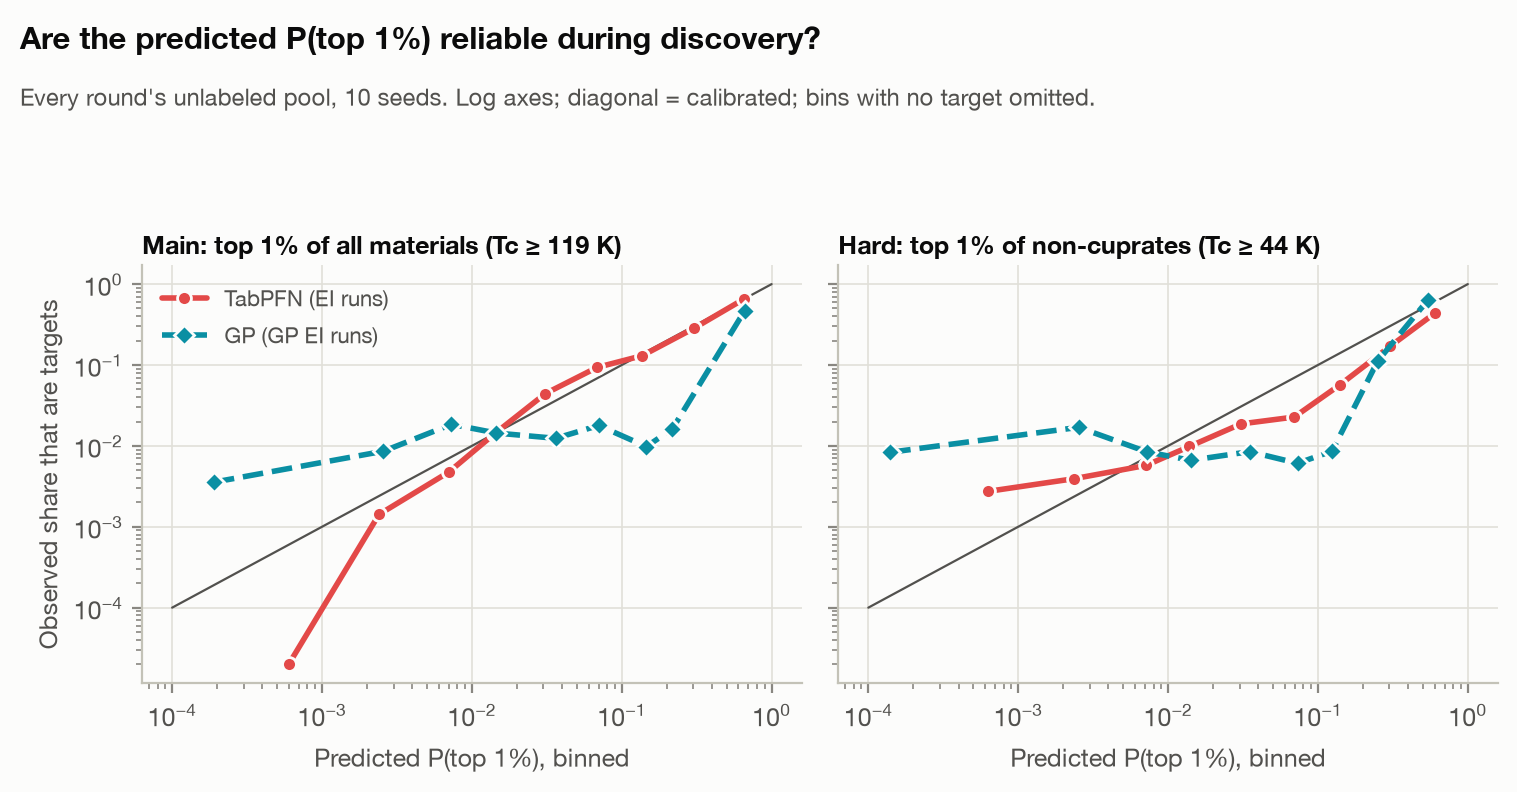

In [2]:
s = pd.read_csv(D / "summary.csv").query("phase == 'main'")
display(
    s[
        [
            "scenario",
            "acquisition",
            "found_50",
            "found_100",
            "found_200",
            "found_200_lo",
            "found_200_hi",
            "first_hit_median",
            "runs_without_hit",
        ]
    ].round(1)
)
p = pd.read_csv(D / "paired.csv")
display(p[p.b == "gp_ei"].round(1))
display(pd.read_csv(D / "paired_by_stall.csv").query("b == 'gp_ei'").round(1))
display(json.loads((D / "gp_fits.json").read_text()))
display(Image(D / "figures" / "reliability.png"))

## 2. Where TabPFN beats tuned XGBoost (grouped split)
Distance = L1 over element fractions from each test row to the nearest training material.

In [3]:
cols = [
    "features",
    "group",
    "rows",
    "share_of_rows",
    "rmse_tabpfn",
    "rmse_xgb",
    "rmse_diff_per_split_mean",
    "rmse_diff_lo",
    "rmse_diff_hi",
    "splits_tabpfn_better",
    "row_win_rate_tabpfn",
    "share_of_mse_advantage",
]
display(pd.read_csv(W / "where_by_distance.csv")[cols].round(3))
sub = pd.read_csv(W / "where_by_subgroup.csv")
display(sub[sub.grouping != "family x distance"][["grouping"] + cols].round(3))
display(sub[(sub.grouping == "family x distance") & (sub.features == "composition")][cols].round(3))

,features,group,rows,share_of_rows,rmse_tabpfn,rmse_xgb,rmse_diff_per_split_mean,rmse_diff_lo,rmse_diff_hi,splits_tabpfn_better,row_win_rate_tabpfn,share_of_mse_advantage
0,composition,< 0.01,72162,0.407,8.922,9.633,-0.714,-0.789,-0.640,25,0.596,0.307
1,composition,0.01-0.05,56223,0.317,8.894,10.191,-1.295,-1.393,-1.197,25,0.650,0.448
2,composition,0.05-0.1,18522,0.104,8.987,9.880,-0.884,-1.036,-0.733,25,0.662,0.100
3,composition,0.1-0.2,13816,0.078,9.685,10.448,-0.769,-1.050,-0.487,22,0.656,0.068
4,composition,>= 0.2,16471,0.093,8.810,9.595,-0.808,-1.034,-0.582,24,0.642,0.077
5,engineered,< 0.01,72162,0.407,9.186,9.631,-0.446,-0.506,-0.386,25,0.581,0.255
6,engineered,0.01-0.05,56223,0.317,8.819,9.768,-0.948,-1.039,-0.857,25,0.642,0.417
7,engineered,0.05-0.1,18522,0.104,8.901,9.768,-0.871,-1.037,-0.705,25,0.656,0.126
8,engineered,0.1-0.2,13816,0.078,9.433,10.282,-0.856,-1.057,-0.655,25,0.641,0.097
9,engineered,>= 0.2,16471,0.093,8.631,9.464,-0.848,-1.067,-0.629,24,0.640,0.104


,grouping,features,group,rows,share_of_rows,rmse_tabpfn,rmse_xgb,rmse_diff_per_split_mean,rmse_diff_lo,rmse_diff_hi,splits_tabpfn_better,row_win_rate_tabpfn,share_of_mse_advantage
0,all,composition,all,177194,1.000,8.971,9.900,-0.928,-0.992,-0.865,25,0.629,1.000
1,family,composition,cuprate,88057,0.497,11.706,12.958,-1.253,-1.347,-1.159,25,0.569,0.875
2,family,composition,iron-based,13992,0.079,7.180,7.898,-0.714,-0.853,-0.575,24,0.598,0.049
3,family,composition,other,75145,0.424,4.429,4.770,-0.361,-0.500,-0.221,21,0.704,0.076
4,tc_band,composition,< 10 K,64252,0.363,4.530,5.172,-0.652,-0.794,-0.510,25,0.708,0.129
5,tc_band,composition,10-77 K,79903,0.451,10.467,11.342,-0.875,-0.941,-0.809,25,0.598,0.490
6,tc_band,composition,>= 77 K,33039,0.186,11.259,12.751,-1.486,-1.638,-1.332,25,0.549,0.381
7,oxygen_missing,composition,False,161054,0.909,8.478,9.337,-0.858,-0.924,-0.793,25,0.637,0.793
8,oxygen_missing,composition,True,16140,0.091,12.901,14.362,-1.449,-1.650,-1.248,25,0.548,0.207
24,all,engineered,all,177194,1.000,9.010,9.726,-0.716,-0.777,-0.655,25,0.618,1.000


,features,group,rows,share_of_rows,rmse_tabpfn,rmse_xgb,rmse_diff_per_split_mean,rmse_diff_lo,rmse_diff_hi,splits_tabpfn_better,row_win_rate_tabpfn,share_of_mse_advantage
9,composition,cuprate / < 0.01,51158,0.289,10.225,11.032,-0.810,-0.893,-0.728,25,0.562,0.282
10,composition,cuprate / 0.01-0.05,27130,0.153,12.102,13.848,-1.739,-1.878,-1.601,25,0.585,0.395
11,composition,cuprate / 0.05-0.1,5330,0.030,15.390,16.930,-1.509,-1.769,-1.249,25,0.565,0.085
12,composition,cuprate / 0.1-0.2,3163,0.018,17.128,18.868,-1.758,-2.151,-1.366,24,0.548,0.064
13,composition,cuprate / >= 0.2,1276,0.007,20.820,23.487,-2.683,-3.323,-2.042,25,0.592,0.048
14,composition,iron-based / < 0.01,5283,0.030,7.166,7.286,-0.137,-0.241,-0.032,19,0.556,0.003
15,composition,iron-based / 0.01-0.05,6212,0.035,6.616,7.398,-0.778,-0.951,-0.604,24,0.619,0.022
16,composition,iron-based / 0.05-0.1,1328,0.008,6.367,7.710,-1.332,-1.665,-0.998,25,0.624,0.008
17,composition,iron-based / 0.1-0.2,772,0.004,8.381,10.652,-2.096,-2.821,-1.371,23,0.663,0.011
18,composition,iron-based / >= 0.2,397,0.002,13.285,14.690,-1.532,-2.374,-0.690,19,0.617,0.005


In [4]:
display(pd.read_csv(W / "worst_materials.csv", keep_default_na=False).head(25).round(2))
json.loads((W / "worst_summary.json").read_text())

,key,formula,family,n_rows,tc_median,tabpfn_pred,xgb_pred,tabpfn_abs_err,xgb_abs_err,nn_distance,nn_tc,oxygen_missing,tc_range_within_material,suspect_phase1
0,H:0.666667 S:0.333333,H2S1,other,2,122.50,7.21,13.05,115.30,109.40,0.74,10.38,False,125.0,non-cuprate above 77 K
1,H:0.200000 O:0.600000 W:0.200000,H1W1O3,other,1,120.00,5.86,2.72,114.10,117.30,0.31,2.76,False,0.0,non-cuprate above 77 K
2,O:0.740741 Na:0.012346 W:0.246914,Na0.05W1O3,other,1,91.00,3.02,2.26,87.98,88.74,0.02,3.98,False,0.0,non-cuprate above 77 K
3,H:0.015385 C:0.938462 Br:0.046154,H1Br3C61,other,1,115.00,29.72,42.54,85.28,72.46,0.10,75.94,False,0.0,non-cuprate above 77 K
4,O:0.524941 Ca:0.142518 Cu:0.223278 Ge:0.014252...,Ge0.3Cu0.7Sr2Ca3Cu4O11.05,cuprate,1,7.00,84.73,85.96,77.73,78.96,0.03,81.67,False,0.0,
5,O:0.600000 Cu:0.200000 Ba:0.120000 Eu:0.080000,Eu0.4Ba0.6Cu1O3,cuprate,1,8.00,79.54,73.49,71.54,65.49,0.11,36.00,False,0.0,
6,O:0.125000 Ca:0.125000 Cu:0.250000 Sb:0.125000...,Sb1Pb1Ca1Ba2Cu2O,cuprate,1,25.00,94.97,91.80,69.97,66.80,0.50,101.80,True,0.0,
7,O:0.526316 Ca:0.105263 Cu:0.157895 Sr:0.105263...,Tl2Sr2Ca2Cu3O10,cuprate,1,16.00,81.31,79.13,65.31,63.13,0.10,75.30,False,0.0,
8,O:0.600000 Cu:0.200000 Ba:0.120000 Gd:0.080000,Gd0.4Ba0.6Cu1O3,cuprate,1,13.00,77.53,62.31,64.53,49.31,0.07,52.17,False,0.0,
9,O:0.103093 Ca:0.206186 Fe:0.020619 Cu:0.288660...,Bi1.5Pb0.2Sr2Ca2Cu2.8Fe0.2O,cuprate,1,24.00,87.99,90.31,63.99,66.31,0.04,101.90,True,0.0,


{'worst_1pct_by_tabpfn_error': {'materials': 151,
  'median_tc_range_within_material_K': 0.0,
  'share_with_tc_range_over_20K': 0.07947019867549669,
  'share_duplicated': 0.12582781456953643,
  'share_oxygen_missing': 0.26490066225165565,
  'median_nn_distance': 0.034708318981996784,
  'family_shares': {'cuprate': 0.9006622516556292,
   'other': 0.08609271523178808,
   'iron-based': 0.013245033112582781},
  'share_xgb_also_off_by_30K': 0.8410596026490066,
  'share_flagged_suspect_in_phase1': 0.046357615894039736},
 'worst_25_by_tabpfn_error': {'materials': 25,
  'median_tc_range_within_material_K': 0.0,
  'share_with_tc_range_over_20K': 0.08,
  'share_duplicated': 0.12,
  'share_oxygen_missing': 0.4,
  'median_nn_distance': 0.06657859703020994,
  'family_shares': {'cuprate': 0.76, 'other': 0.24},
  'share_xgb_also_off_by_30K': 1.0,
  'share_flagged_suspect_in_phase1': 0.24},
 'all_materials': {'materials': 15163,
  'median_tc_range_within_material_K': 0.0,
  'share_with_tc_range_over_2

## 3. Why greedy search stalls

{'main': {'target_chemistry': 'contains Hg or Tl',
  'share_targets_in_target_chemistry': 0.9342105263157895,
  'stall_seeds_both_greedy': [0, 4, 8],
  'top_systems_stalled_greedy_picks': [['Ba-Cu-Y', 101, 0.084],
   ['Ba-Cu-Hg', 92, 0.077],
   ['Ba-Cu-La-Y', 75, 0.062],
   ['Ba-Cu-Pr-Y', 71, 0.059],
   ['Ba-Cu-Sr-Y', 47, 0.039]],
  'top_systems_ei_picks_same_seeds': [['Ba-Ca-Cu-Tl', 50, 0.083],
   ['Ba-Ca-Cu-Hg', 45, 0.075],
   ['Ba-Ca-Cu-Hg-Tl', 38, 0.063],
   ['Ba-Ca-Cu-Hg-Pb', 34, 0.057],
   ['Ba-Ca-Cu-F-Hg', 32, 0.053]]},
 'hard': {'target_chemistry': 'iron-based',
  'share_targets_in_target_chemistry': 0.9620253164556962,
  'stall_seeds_both_greedy': [0, 1, 2, 3],
  'top_systems_stalled_greedy_picks': [['B-C-Mg', 214, 0.134],
   ['Al-B-Mg', 193, 0.121],
   ['As-Ba-Fe-K', 69, 0.043],
   ['B-Li-Mg', 68, 0.043],
   ['B-Cu-Mg', 64, 0.04]],
  'top_systems_ei_picks_same_seeds': [['As-F-Fe-Nd', 30, 0.037],
   ['As-F-Fe-Sm', 28, 0.035],
   ['As-Fe-H-Sm', 23, 0.029],
   ['Al-B-Mg', 20, 0.

,scenario,acquisition,stalled,runs,mean_pick_tc,mean_pick_pred,best_tc_round_5,best_tc_round_20,share_picks_target_chem,median_pick_tc,start_max_tc,best_tc_round_20_max
0,hard,ei,False,10,28.53,30.99,46.26,55.38,0.70,29.60,36.48,55.60
1,hard,gp_ei,False,4,28.20,30.89,46.58,55.45,0.76,30.02,35.75,55.60
2,hard,gp_ei,True,6,24.14,27.34,40.76,43.79,0.10,29.21,36.96,50.00
3,hard,greedy_tabpfn,False,6,33.30,34.46,47.86,53.83,0.71,35.07,35.58,55.60
4,hard,greedy_tabpfn,True,4,31.59,32.92,40.98,42.98,0.21,34.61,37.82,44.55
5,hard,greedy_xgb,False,6,34.02,36.48,53.19,55.33,0.95,35.49,35.58,55.60
6,hard,greedy_xgb,True,4,31.67,32.71,40.28,43.12,0.26,33.81,37.82,47.20
7,main,ei,False,10,98.58,99.24,130.63,139.26,0.75,112.56,102.90,143.00
8,main,gp_ei,False,7,76.84,91.49,123.74,134.30,0.50,94.64,106.63,135.80
9,main,gp_ei,True,3,72.69,73.40,106.50,116.33,0.02,83.95,94.20,130.00


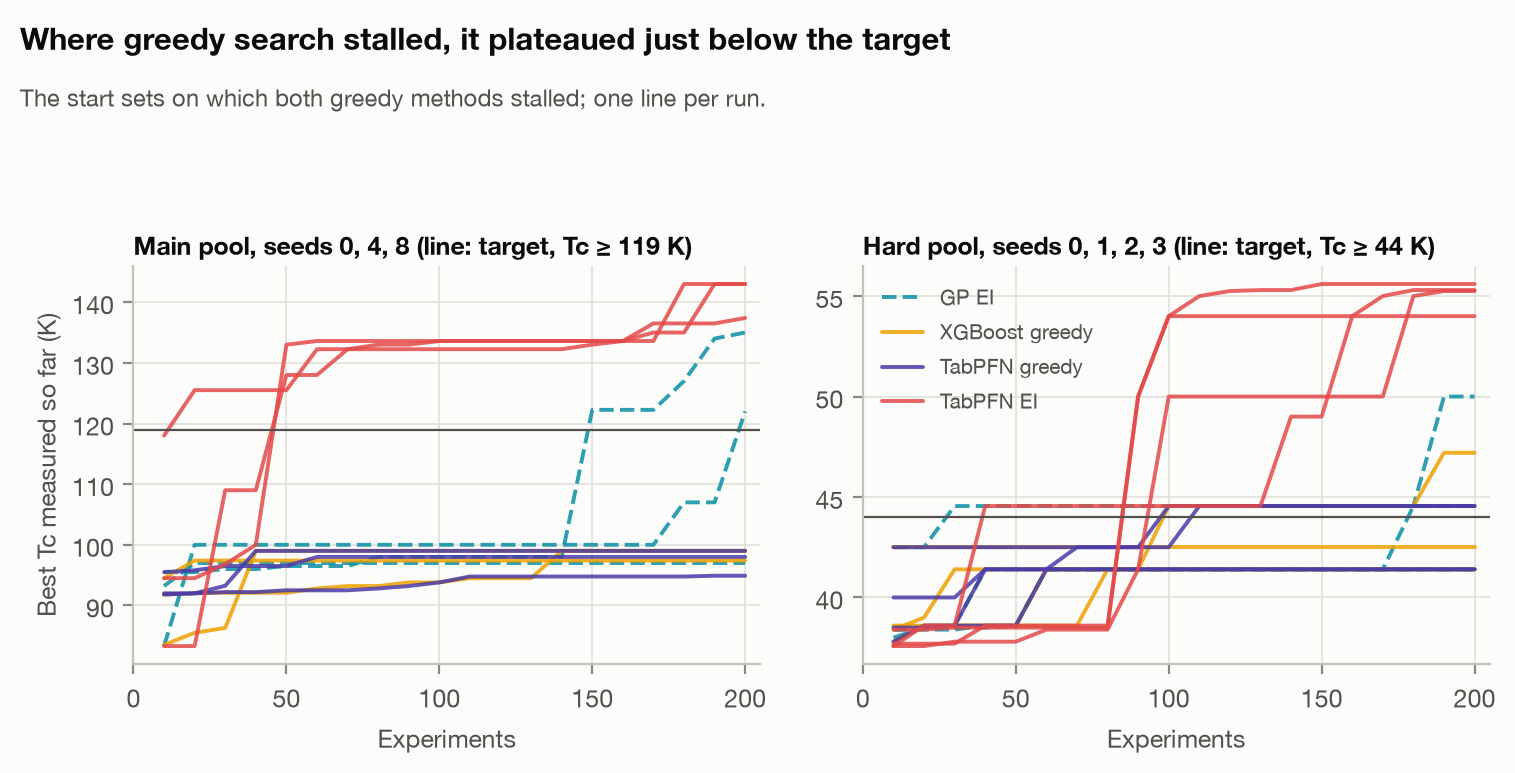

In [5]:
summary = json.loads((W / "stall_summary.json").read_text())
display({k: v for k, v in summary.items() if k not in ("by_method_and_stall",)})
display(pd.DataFrame(summary["by_method_and_stall"]).round(2))
display(Image(W / "figures" / "stalls.png"))

In [6]:
pd.read_csv(W / "stall_round1.csv").round(2)

,scenario,seed,acquisition,pred_mean,pred_upper_spread,p_top1,realised_tc,targets,share_target_chem
0,main,0,ei,65.83,32.90,0.04,66.71,0,1.0
1,main,0,greedy_tabpfn,82.86,14.45,0.02,79.43,0,0.4
2,main,1,ei,60.72,40.50,0.03,9.75,0,0.6
3,main,1,greedy_tabpfn,96.49,6.89,0.00,121.05,6,1.0
4,main,2,ei,78.05,29.40,0.05,49.36,0,0.1
5,main,2,greedy_tabpfn,98.29,4.54,0.00,97.90,0,0.0
6,main,3,ei,95.86,24.22,0.11,117.46,5,1.0
7,main,3,greedy_tabpfn,98.38,18.33,0.06,113.54,3,0.4
8,main,4,ei,55.22,37.73,0.05,65.00,0,0.4
9,main,4,greedy_tabpfn,70.53,25.63,0.02,86.05,0,0.0


## 4. What sets the width of TabPFN's intervals?

,split_kind,held_out,model,spearman_width_distance,spearman_width_knn10_tc_sd,spearman_width_abs_error
0,grouped,all,conformal,NaN,NaN,NaN
1,grouped,all,quantile_regression,-0.285,0.826,0.640
2,grouped,all,tabpfn,-0.186,0.831,0.740
3,leave_family_out,cuprate,conformal,NaN,NaN,NaN
4,leave_family_out,cuprate,quantile_regression,-0.158,-0.204,0.260
5,leave_family_out,cuprate,tabpfn,-0.449,0.418,0.019
6,leave_family_out,iron-based,conformal,NaN,NaN,NaN
7,leave_family_out,iron-based,quantile_regression,-0.142,0.204,0.248
8,leave_family_out,iron-based,tabpfn,0.048,0.013,-0.027
9,leave_family_out,other,conformal,NaN,NaN,NaN


,split_kind,held_out,family,model,distance,rows,coverage_80,coverage_95,width_80,width_95,rmse
0,grouped,all,all,tabpfn,< 0.01,72162,0.812,0.951,16.711,28.917,8.922
1,grouped,all,all,tabpfn,0.01-0.05,56223,0.839,0.964,16.921,28.958,8.894
2,grouped,all,all,tabpfn,0.05-0.1,18522,0.836,0.964,15.024,25.255,8.987
3,grouped,all,all,tabpfn,0.1-0.2,13816,0.818,0.962,15.609,25.676,9.685
4,grouped,all,all,tabpfn,>= 0.2,16471,0.829,0.962,10.797,18.152,8.810
5,grouped,all,cuprate,tabpfn,< 0.01,51158,0.810,0.949,20.930,36.044,10.225
6,grouped,all,cuprate,tabpfn,0.01-0.05,27130,0.838,0.965,28.322,47.897,12.102
7,grouped,all,cuprate,tabpfn,0.05-0.1,5330,0.820,0.970,36.936,60.561,15.390
8,grouped,all,cuprate,tabpfn,0.1-0.2,3163,0.833,0.963,43.024,68.346,17.128
9,grouped,all,cuprate,tabpfn,>= 0.2,1276,0.842,0.970,51.471,77.610,20.820


,split_kind,held_out,model,knn10_tc_sd,rows,coverage_80,coverage_95,width_80,width_95,rmse
0,grouped,all,tabpfn,< 2,44824,0.837,0.961,3.247,6.318,3.216
1,grouped,all,tabpfn,2-5,40308,0.822,0.957,8.542,15.691,5.280
2,grouped,all,tabpfn,5-10,41368,0.815,0.956,18.583,32.499,8.774
3,grouped,all,tabpfn,10-20,36683,0.829,0.962,28.261,47.038,12.108
4,grouped,all,tabpfn,20-30,12412,0.819,0.954,37.565,59.893,16.384
5,grouped,all,tabpfn,>= 30,1599,0.773,0.944,42.196,67.130,22.080
18,leave_family_out,cuprate,tabpfn,< 2,280,0.361,0.764,38.473,83.872,49.591
19,leave_family_out,cuprate,tabpfn,2-5,903,0.166,0.574,37.868,82.088,60.260
20,leave_family_out,cuprate,tabpfn,5-10,2833,0.269,0.684,39.369,82.288,54.181
21,leave_family_out,cuprate,tabpfn,10-20,1859,0.419,0.841,35.545,77.786,40.599


,0,1,2
held_out,cuprate,iron-based,other
rows,10532,1682,9049
nn_distance_median,0.62,0.8,1.454
share_nn_within_0.05,0.001,0.001,0.006
share_nn_family_cuprate,0.0,0.001,0.611
share_nn_family_iron-based,0.005,0.0,0.389
share_nn_family_other,0.995,0.999,0.0
tc_median,63.1,20.0,4.5
nn_tc_median,22.0,2.8,20.0
knn10_tc_mean_median,18.943,4.374,35.78


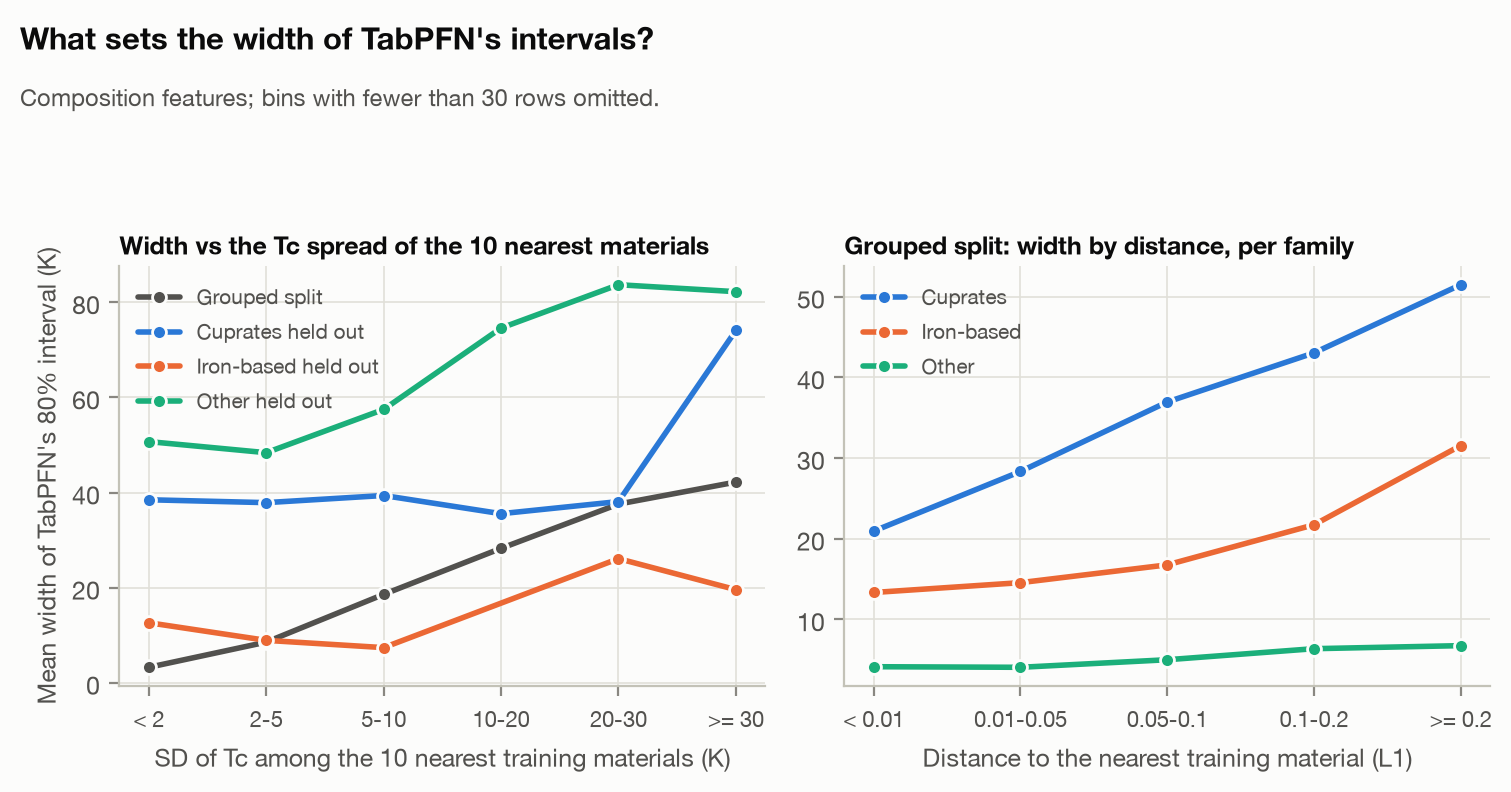

In [7]:
display(pd.read_csv(W / "width_drivers.csv").round(3))
d = pd.read_csv(W / "interval_vs_distance.csv")
display(d[(d.model == "tabpfn") & (d.split_kind == "grouped")].round(3))
n = pd.read_csv(W / "interval_vs_neighbour_spread.csv")
display(n[n.model == "tabpfn"].round(3))
display(pd.read_csv(W / "lfo_neighbours.csv").round(3).T)
display(Image(W / "figures" / "interval_width_drivers.png"))

## 5. Is Hamidieh's top feature a cuprate detector?

In [8]:
r = json.loads((W / "cuprate_detector.json").read_text())
display(r["alone"])
display(r["summary"])
g = pd.read_csv(W / "feature_gain.csv")
g.groupby("variant").head(6).round(4)

{'roc_auc_for_cuprate': 0.9932256768187038,
 'most_common_value_among_cuprates': 399.973,
 'share_cuprate_rows_at_that_value': 0.9892707937713635,
 'share_non_cuprate_rows_at_that_value': 0.0,
 'share_rows_at_that_value_that_are_cuprates': 1.0}

{'published': {'splits': 5,
  'rmse_mean': 9.768795675940357,
  'gain_share_range_ThermalConductivity_mean': 0.2299409718385109,
  'gain_share_is_cuprate_mean': nan},
 'published + is_cuprate': {'splits': 5,
  'rmse_mean': 9.745178318096734,
  'gain_share_range_ThermalConductivity_mean': 0.10488696669445426,
  'gain_share_is_cuprate_mean': 0.2772821347606403}}

,variant,feature,gain_share
0,published,range_ThermalConductivity,0.2299
1,published,range_atomic_radius,0.1167
2,published,wtd_std_ThermalConductivity,0.1038
3,published,wtd_gmean_ThermalConductivity,0.0437
4,published,wtd_entropy_Valence,0.0311
5,published,wtd_gmean_Valence,0.0295
81,published + is_cuprate,is_cuprate,0.2773
82,published + is_cuprate,range_ThermalConductivity,0.1049
83,published + is_cuprate,range_atomic_radius,0.0592
84,published + is_cuprate,wtd_gmean_ThermalConductivity,0.0591
